# Benin EDA — Solar Dataset
**Objective:** Profile, clean and explore the sierraleone solar dataset end-to-end according to Task 2.
- Author: Ruhama B.
- Branch: `eda-sierraleone`
- Data: `data/sierraleone-bumbuna.csv` -> cleaned export `data/sierraleone_clean.csv` (do **not** commit CSVs)


## Imports and plotting configuration

Here we import essential libraries:
- `pandas` and `numpy` for data handling
- `matplotlib` and `seaborn` for plotting
- `scipy.stats` for Z-score calculations


In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set default plotting style
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

# Helper to safely show plots in any environment
def safe_show():
    try:
        display(plt.gcf())
    except Exception:
        pass


## Load the sierraleone solar dataset

- Define input  and output  paths
- Ensure the CSV exists in `data/`
- Load into a Pandas DataFrame


In [3]:
DATA_IN = r"C:\Users\ruham\Downloads\solar-challenge-week0\solar-challenge-week0\data/sierraleone-bumbuna.csv"
DATA_OUT = r"C:\Users\ruham\Downloads\solar-challenge-week0\solar-challenge-week0\data/sierraleone-bumbuna_clean.csv"

import pandas as pd

try:
    df = pd.read_csv(DATA_IN)
    print("Loaded data shape:", df.shape)
    display(df.head())
except FileNotFoundError:
    print(f"Error: '{DATA_IN}' not found. Check the path.")


Loaded data shape: (525600, 19)


,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
0,2021-10-30 00:01,-0.7,-0.1,-0.8,0.0,0.0,21.9,99.1,0.0,0.0,0.0,0.0,0.0,1002,0,0.0,22.3,22.6,NaN
1,2021-10-30 00:02,-0.7,-0.1,-0.8,0.0,0.0,21.9,99.2,0.0,0.0,0.0,0.0,0.0,1002,0,0.0,22.3,22.6,NaN
2,2021-10-30 00:03,-0.7,-0.1,-0.8,0.0,0.0,21.9,99.2,0.0,0.0,0.0,0.0,0.0,1002,0,0.0,22.3,22.6,NaN
3,2021-10-30 00:04,-0.7,0.0,-0.8,0.0,0.0,21.9,99.3,0.0,0.0,0.0,0.0,0.0,1002,0,0.1,22.3,22.6,NaN
4,2021-10-30 00:05,-0.7,-0.1,-0.8,0.0,0.0,21.9,99.3,0.0,0.0,0.0,0.0,0.0,1002,0,0.0,22.3,22.6,NaN


## Inspect data types and numeric summary

- `df.info()` shows column types and memory usage
- `df.describe()` provides basic statistics for numeric columns


In [4]:
print("----- dtypes & memory -----")
display(df.info())
print("\n----- Numeric summary -----")
display(df.describe(include=[np.number]).T)


----- dtypes & memory -----
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525600 entries, 0 to 525599
Data columns (total 19 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Timestamp      525600 non-null  object 
 1   GHI            525600 non-null  float64
 2   DNI            525600 non-null  float64
 3   DHI            525600 non-null  float64
 4   ModA           525600 non-null  float64
 5   ModB           525600 non-null  float64
 6   Tamb           525600 non-null  float64
 7   RH             525600 non-null  float64
 8   WS             525600 non-null  float64
 9   WSgust         525600 non-null  float64
 10  WSstdev        525600 non-null  float64
 11  WD             525600 non-null  float64
 12  WDstdev        525600 non-null  float64
 13  BP             525600 non-null  int64  
 14  Cleaning       525600 non-null  int64  
 15  Precipitation  525600 non-null  float64
 16  TModA          525600 non-null  float64
 17  T

None


----- Numeric summary -----


,count,mean,std,min,25%,50%,75%,max
GHI,525600.0,201.957515,298.495150,-19.5,-2.8,0.3,362.4,1499.0
DNI,525600.0,116.376337,218.652659,-7.8,-0.3,-0.1,107.0,946.0
DHI,525600.0,113.720571,158.946032,-17.9,-3.8,-0.1,224.7,892.0
ModA,525600.0,206.643095,300.896893,0.0,0.0,3.6,359.5,1507.0
ModB,525600.0,198.114691,288.889073,0.0,0.0,3.4,345.4,1473.0
Tamb,525600.0,26.319394,4.398605,12.3,23.1,25.3,29.4,39.9
RH,525600.0,79.448857,20.520775,9.9,68.7,85.4,96.7,100.0
WS,525600.0,1.146113,1.239248,0.0,0.0,0.8,2.0,19.2
WSgust,525600.0,1.691606,1.617053,0.0,0.0,1.6,2.6,23.9
WSstdev,525600.0,0.363823,0.295000,0.0,0.0,0.4,0.6,4.1


## Missing values analysis

- Count missing values per column
- Compute % of missing values
- Identify columns with >5% missing values


In [5]:
missing = df.isna().sum()
missing_pct = (missing / len(df)) * 100
missing_table = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
display(missing_table.sort_values("missing_pct", ascending=False))

cols_over_5pct = missing_table[missing_table["missing_pct"] > 5]
if cols_over_5pct.empty:
    print("No columns with >5% missing values.")
else:
    print("Columns with >5% missing values:")
    display(cols_over_5pct)


,missing_count,missing_pct
Comments,525600,100.0
GHI,0,0.0
Timestamp,0,0.0
DNI,0,0.0
DHI,0,0.0
ModB,0,0.0
ModA,0,0.0
RH,0,0.0
WS,0,0.0
WSgust,0,0.0


Columns with >5% missing values:


,missing_count,missing_pct
Comments,525600,100.0


## Identify key columns for cleaning & outlier detection

- Focus on main solar and sensor measurements: GHI, DNI, DHI, ModA, ModB, WS, WSgust
- Check which of these exist in the dataset


In [6]:
KEY_COLS = ['GHI','DNI','DHI','ModA','ModB','WS','WSgust']

present_key_cols = [c for c in KEY_COLS if c in df.columns]
missing_key_cols = [c for c in KEY_COLS if c not in df.columns]
print("Present key columns:", present_key_cols)
if missing_key_cols:
    print("Warning: missing expected key columns:", missing_key_cols)


Present key columns: ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust']


## Flag outliers using Z-scores

- Compute Z-scores for each numeric key column
- Flag rows where |Z| > 3
- Store results in `z_outlier_flag` column


In [7]:
if present_key_cols:
    numeric_block = df[present_key_cols].select_dtypes(include=[np.number])
    if numeric_block.shape[1] == 0 or numeric_block.dropna(how='all').empty:
        print("No numeric data available for Z-score calculation.")
        df['z_outlier_flag'] = False
    else:
        z = np.abs(stats.zscore(numeric_block, nan_policy='omit'))
        if z.ndim == 1:
            z = z.reshape(-1, 1)
        z_flag = (z > 3).any(axis=1)
        df['z_outlier_flag'] = z_flag
        print("Number of rows flagged as outliers (|Z|>3) in key columns:", df['z_outlier_flag'].sum())
else:
    print("No key columns present — skipping Z-score check.")
    df['z_outlier_flag'] = False


Number of rows flagged as outliers (|Z|>3) in key columns: 16292


## Apply cleaning: Impute missing values

- Use **median** for key columns (robust to outliers)
- Keep `z_outlier_flag` for later review


In [8]:
df_clean = df.copy()

for col in present_key_cols:
    if df_clean[col].isnull().any():
        med = df_clean[col].median()
        df_clean[col].fillna(med, inplace=True)
        print(f"Imputed median for {col}: {med}")

print("After imputation shape:", df_clean.shape)


After imputation shape: (525600, 20)


## Save the cleaned dataset

- Export to `data/benin_clean.csv`
- **Do not commit this file** — it is in `.gitignore`


In [9]:
os.makedirs("data", exist_ok=True)
df_clean.to_csv(DATA_OUT, index=False)
print("Cleaned data exported to:", DATA_OUT)


Cleaned data exported to: C:\Users\ruham\Downloads\solar-challenge-week0\solar-challenge-week0\data/sierraleone-bumbuna_clean.csv


## Time Series Analysis
In this step, we convert the `Timestamp` column to datetime, sort the data, and plot key solar irradiance variables (GHI, DNI, DHI) over time. This helps us identify trends, seasonal patterns, and anomalies.


Timestamps converted. Range: 2021-10-30 00:01:00 -> 2022-10-30 00:00:00


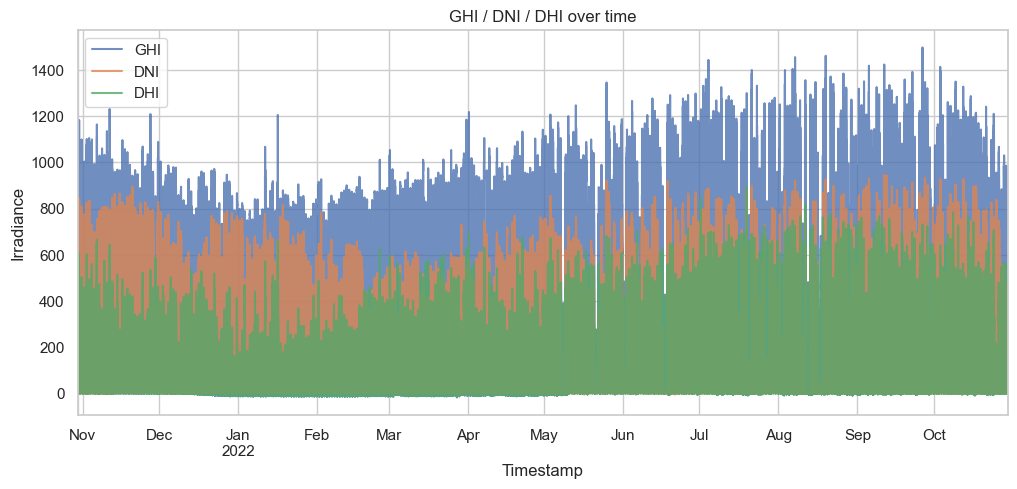

In [10]:
# Convert Timestamp safely and sort
if 'Timestamp' in df_clean.columns:
    df_clean['Timestamp'] = pd.to_datetime(df_clean['Timestamp'], errors='coerce')
    df_clean = df_clean.sort_values('Timestamp').reset_index(drop=True)
    print("Timestamps converted. Range:", df_clean['Timestamp'].min(), "->", df_clean['Timestamp'].max())
else:
    print("No 'Timestamp' column found — time-series plots will be skipped.")

# Plot GHI, DNI, DHI vs Timestamp (if present)
if 'Timestamp' in df_clean.columns and any(c in df_clean.columns for c in ['GHI','DNI','DHI']):
    cols_to_plot = [c for c in ['GHI','DNI','DHI'] if c in df_clean.columns]
    df_clean.set_index('Timestamp', inplace=True)
    df_clean[cols_to_plot].plot(alpha=0.8)
    plt.title("GHI / DNI / DHI over time")
    plt.ylabel("Irradiance")
    plt.show()
    df_clean.reset_index(inplace=True)
else:
    print("Skipping irradiance time series - required columns missing.")
